In [153]:
import numpy as np
import scipy.linalg as lin
import matplotlib.pyplot as plt

[2 5]


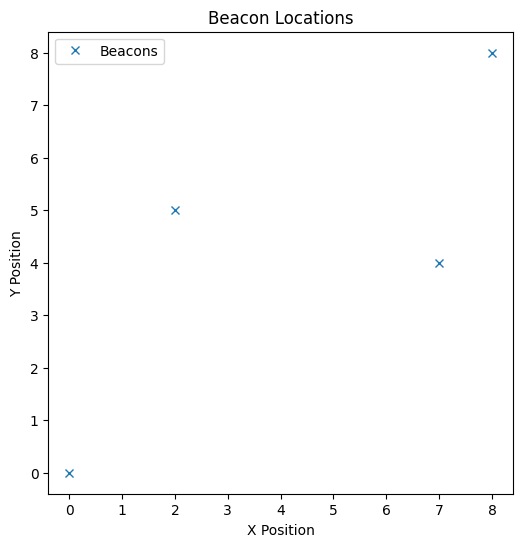

In [154]:
# System
from numpy import eye
from sympy import plot


Ac = np.array([[0 , 0, 1, 0],
              [0 , 0, 0, 1],
              [0 , 0, 0, 0],
              [0 , 0, 0, 0]])

speed = 0.05

# Discretization
dt = 0.01
A = eye(4) + Ac*dt

# Dh/dx
def dh_dx1(x, b):
    return (x[0] - b[0]) / np.sqrt((x[0] - b[0])**2 + (x[1] - b[1])**2)
def dh_dx2(x, b):
    return (x[1] - b[1]) / np.sqrt((x[0] - b[0])**2 + (x[1] - b[1])**2)

def h_func(x, beacons):
    return np.array([np.sqrt((x[0] - b[0])**2 + (x[1] - b[1])**2) for b in beacons])

# Beacon locations
beacons = np.array([[0, 0],
                    [8, 8],
                    [7, 4],
                    [2, 5]])

print(beacons[3,:])

plt.figure(figsize=(6, 6))
plt.plot(beacons[:, 0], beacons[:, 1], 'x', label='Beacons')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Beacon Locations')
plt.legend()
plt.show()


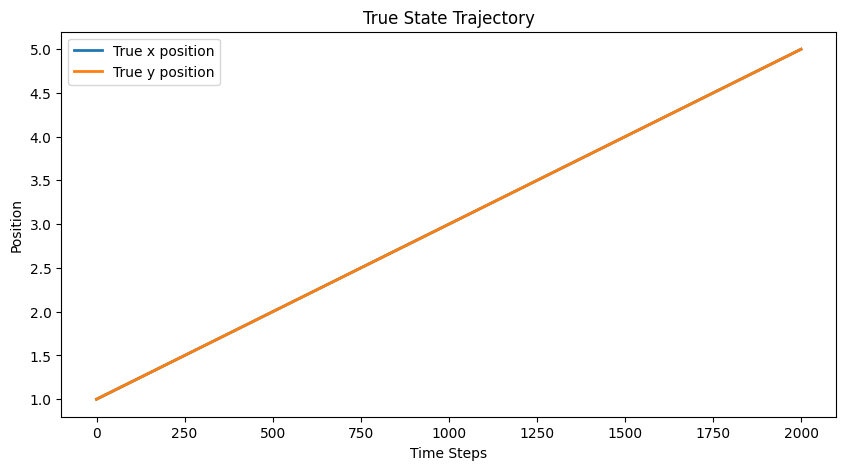

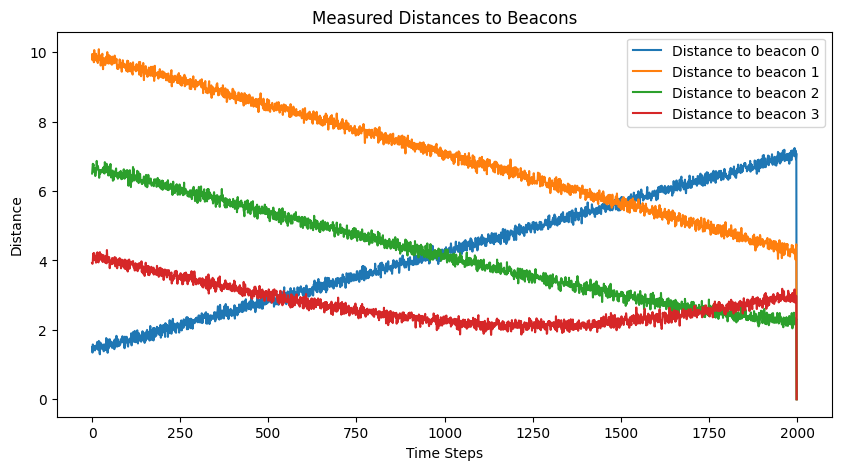

In [155]:
nx = 4
ny = 4

N = 2000
times = np.arange(N)

x = np.zeros((nx, N))
y = np.zeros((ny, N))
v = np.zeros((ny, N))
w = np.zeros((nx, N))

x[:,0] = np.array([1, 1, 0.2, 0.2])

for k in range(N-1):
    # Ck = np.array([[dh_dx1(x, beacons[0,:]), dh_dx2(x, beacons[0,:]), 0, 0],
    #           [dh_dx1(x, beacons[1,:]), dh_dx2(x, beacons[1,:]), 0, 0],
    #           [dh_dx1(x, beacons[2,:]), dh_dx2(x, beacons[2,:]), 0, 0],
    #           [dh_dx1(x, beacons[3,:]), dh_dx2(x, beacons[3,:]), 0, 0]])
    y[:,k] = h_func(x[:,k], beacons) + 0.1 * np.random.randn(ny)
    x[:,k+1] = A @ x[:,k]

# plt.figure(figsize=(10, 5))
# plt.plot(times, x[0,:], label='x1')
# plt.plot(times, x[1,:], label='x2')
# plt.plot(times, y[1,:], label='y1')
# plt.xlabel('Time Steps')
# plt.ylabel('State Values')
# plt.title('State Evolution Over Time')
# plt.legend()
# plt.show()

# Plot true trajectory
plt.figure(figsize=(10, 5))
plt.plot(times, x[0,:], label='True x position', linewidth=2)
plt.plot(times, x[1,:], label='True y position', linewidth=2)
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.title('True State Trajectory')
plt.legend()
plt.show()

# Plot true distances
plt.figure(figsize=(10, 5))
for i in range(ny):
    plt.plot(times, y[i,:], label=f'Distance to beacon {i}')
plt.xlabel('Time Steps')
plt.ylabel('Distance')
plt.title('Measured Distances to Beacons')
plt.legend()
plt.show()



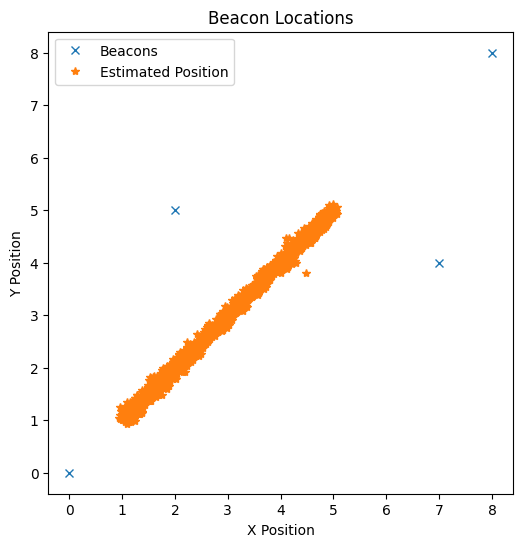

In [156]:
# Esimation

xhat = np.zeros((nx, N))
xhat[:,0] = np.array([1, 1, 0, 0])
P = np.zeros((nx, nx, N))

meanNoiseVar = 1
R = meanNoiseVar * np.eye(ny)
Q = 0.5 * np.eye(nx)



for k in range(N-1):
    xhat[:,k]
    PCur = P[:,:,k]
    # Prediction
    
    xhatPred = A @ xhat[:,k]
    PPred = A @ PCur @ A.T + Q

    # Measurement update
    ymeas = y[:,k+1]
    H = np.array([[dh_dx1(xhatPred, beacons[0,:]), dh_dx2(xhatPred, beacons[0,:]), 0, 0],
              [dh_dx1(xhatPred, beacons[1,:]), dh_dx2(xhatPred, beacons[1,:]), 0, 0],
              [dh_dx1(xhatPred, beacons[2,:]), dh_dx2(xhatPred, beacons[2,:]), 0, 0],
              [dh_dx1(xhatPred, beacons[3,:]), dh_dx2(xhatPred, beacons[3,:]), 0, 0]])
    hWithoutNoise = h_func(xhatPred, beacons)
    Kgain = PPred @ H.T @ lin.inv(H @ PPred @ H.T + R)
    xhatNext = xhatPred + Kgain @ (ymeas - hWithoutNoise)
    PNext = (np.eye(nx) - Kgain @ H) @ PPred

    # Assign results
    xhat[:,k+1] = xhatNext
    P[:,:,k+1] = PNext


plt.figure(figsize=(6, 6))
plt.plot(beacons[:, 0], beacons[:, 1], 'x', label='Beacons')
plt.plot(xhat[0,:], xhat[1,:], '*' , label='Estimated Position')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Beacon Locations')
plt.legend()
plt.show()


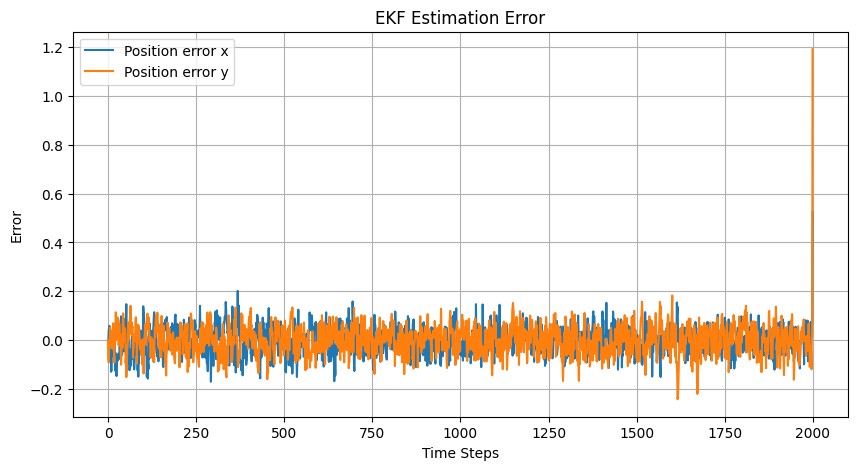

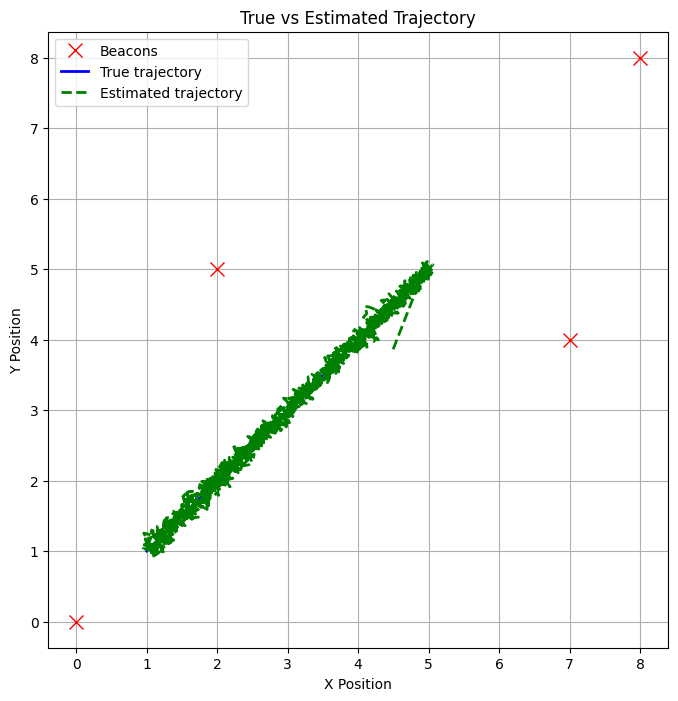

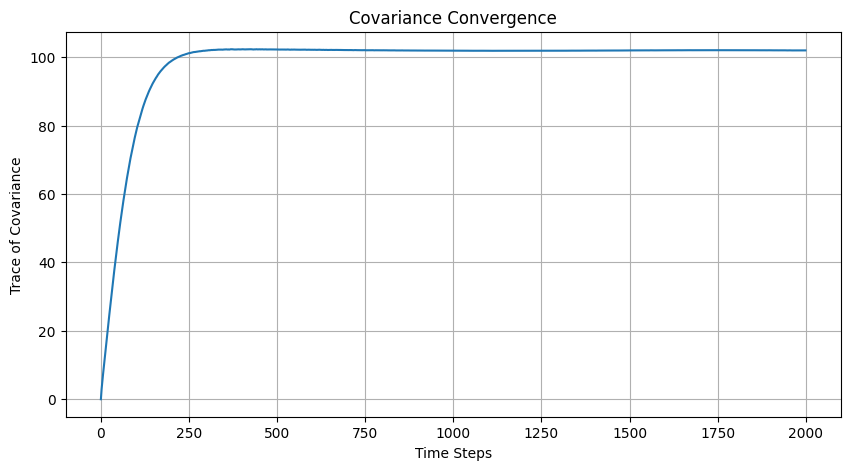

In [162]:
# Plot estimation error
plt.figure(figsize=(10, 5))
plt.plot(times, x[0,:] - xhat[0,:], label='Position error x')
plt.plot(times, x[1,:] - xhat[1,:], label='Position error y')
plt.xlabel('Time Steps')
plt.ylabel('Error')
plt.title('EKF Estimation Error')
plt.legend()
plt.grid()
plt.show()

# Plot true vs estimated trajectory
plt.figure(figsize=(8, 8))
plt.plot(beacons[:, 0], beacons[:, 1], 'rx', markersize=10, label='Beacons')
plt.plot(x[0,:], x[1,:], 'b-', label='True trajectory', linewidth=2)
plt.plot(xhat[0,:], xhat[1,:], 'g--', label='Estimated trajectory', linewidth=2)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('True vs Estimated Trajectory')
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

# Check convergence: covariance trace should decrease
trace_P = [np.trace(P[:,:,k]) for k in range(N)]
plt.figure(figsize=(10, 5))
plt.plot(times, trace_P)
plt.xlabel('Time Steps')
plt.ylabel('Trace of Covariance')
plt.title('Covariance Convergence')
plt.grid()
plt.show()